# **1. Dataset Introduction**


The dataset used is the **Heart Disease Dataset** from the UCI Machine Learning Repository (available on Kaggle).

This dataset contains clinical patient data used to predict whether a person has heart disease.

**Features (13 input columns):**
- `age` — patient age
- `sex` — gender (1 = male, 0 = female)
- `cp` — chest pain type (0–3)
- `trestbps` — resting blood pressure
- `chol` — serum cholesterol level
- `fbs` — fasting blood sugar > 120 mg/dl (1 = yes)
- `restecg` — resting electrocardiographic results (0–2)
- `thalach` — maximum heart rate
- `exang` — exercise-induced angina (1 = yes)
- `oldpeak` — ST depression induced by exercise
- `slope` — slope of the peak ST segment
- `ca` — number of major vessels (0–3)
- `thal` — thalassemia (0–3)

**Target:** `target` (1 = heart disease present, 0 = no heart disease)

**Source:** UCI ML Repository via Kaggle — https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

# **2. Import Library**

Importing the required Python libraries for data analysis and machine learning model building.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print('Libraries imported successfully!')

Libraries imported successfully!


# **3. Loading Dataset**

The Heart Disease dataset is loaded from a CSV file downloaded from Kaggle. The dataset is also saved as a backup in the `heart_raw/` folder.

In [2]:
# Load dataset
df = pd.read_csv('heart.csv')

# Simpan raw data
os.makedirs('heart_raw', exist_ok=True)
df.to_csv('heart_raw/heart.csv', index=False)

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print(f'\nFirst few rows:')
df.head()

Dataset berhasil dimuat!
Shape: (1025, 14)

Beberapa baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **4. Exploratory Data Analysis (EDA)**

Performing EDA to understand the dataset characteristics before preprocessing and model training.

In [3]:
# --- 4.1 Basic Information ---
print('=== DATASET INFO ===')
print(df.info())
print('\n=== DESCRIPTIVE STATISTICS ===')
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

=== STATISTIK DESKRIPTIF ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
# --- 4.2 Check Missing Values and Duplicates ---
print('=== MISSING VALUES ===')
print(df.isnull().sum())

print('\n=== DUPLICATES ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== TARGET DISTRIBUTION ===')
print(df['target'].value_counts())
print(f'\nPercentage: {df["target"].value_counts(normalize=True).round(3) * 100}')

=== MISSING VALUES ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== DUPLIKAT ===
Jumlah baris duplikat: 723

=== DISTRIBUSI TARGET ===
target
1    526
0    499
Name: count, dtype: int64

Presentase: target
1    51.3
0    48.7
Name: proportion, dtype: float64


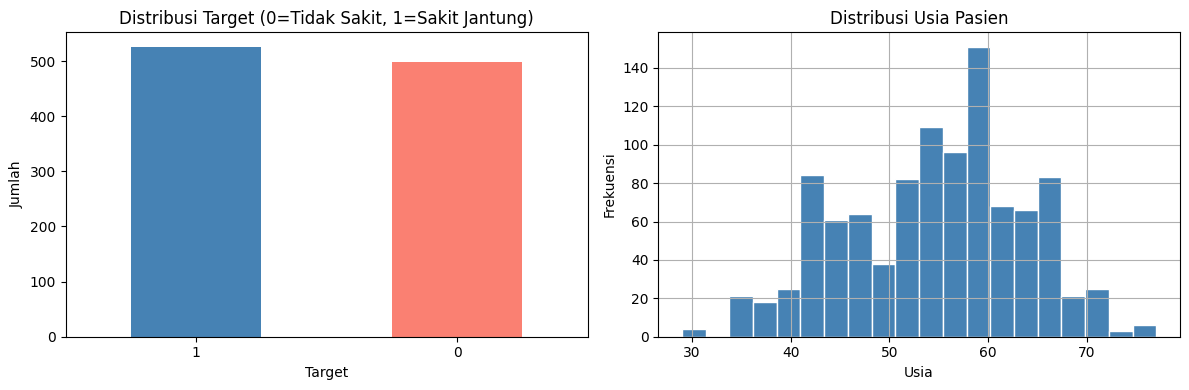

In [5]:
# --- 4.3 Visualize Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart target
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Target Distribution (0=No Disease, 1=Heart Disease)')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Distribusi usia
df['age'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Patient Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

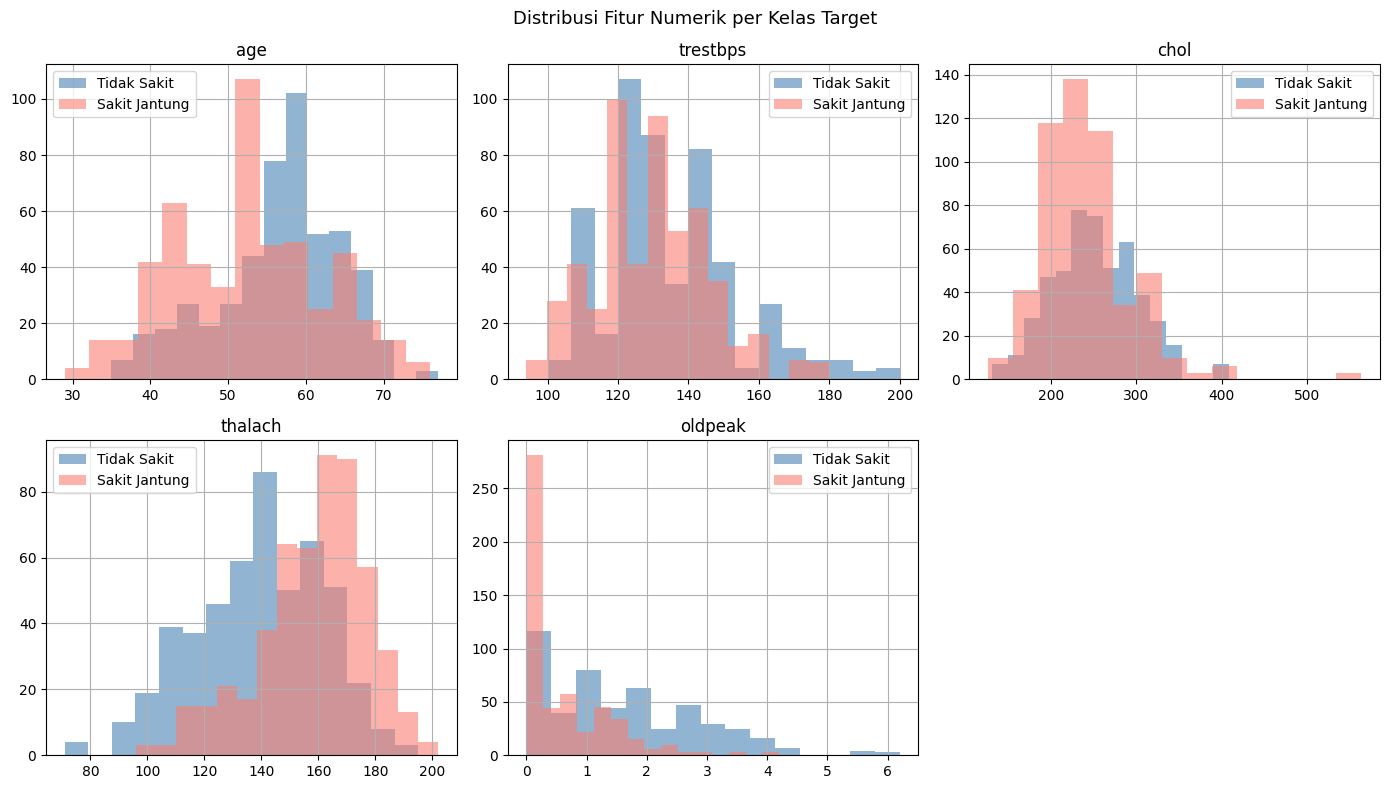

In [6]:
# --- 4.4 Numerical Feature Distribution ---
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for idx, (ax, col) in enumerate(zip(axes.flatten(), numerical_cols)):
    for target_val, color, label in [(0, 'steelblue', 'No Disease'), (1, 'salmon', 'Heart Disease')]:
        df[df['target'] == target_val][col].hist(alpha=0.6, bins=15, ax=ax, color=color, label=label)
    ax.set_title(col)
    ax.legend()

# Remove empty subplot
fig.delaxes(axes[1][2])
plt.suptitle('Numerical Feature Distribution by Target Class', fontsize=13)
plt.tight_layout()
plt.show()

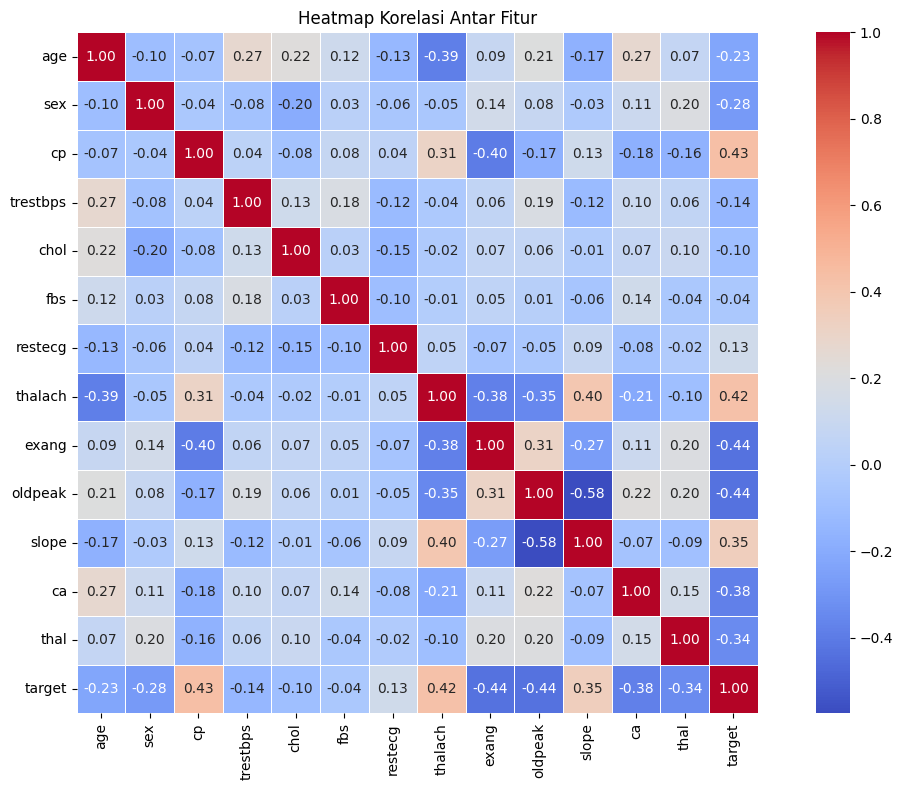

In [7]:
# --- 4.5 Correlation Heatmap ---
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

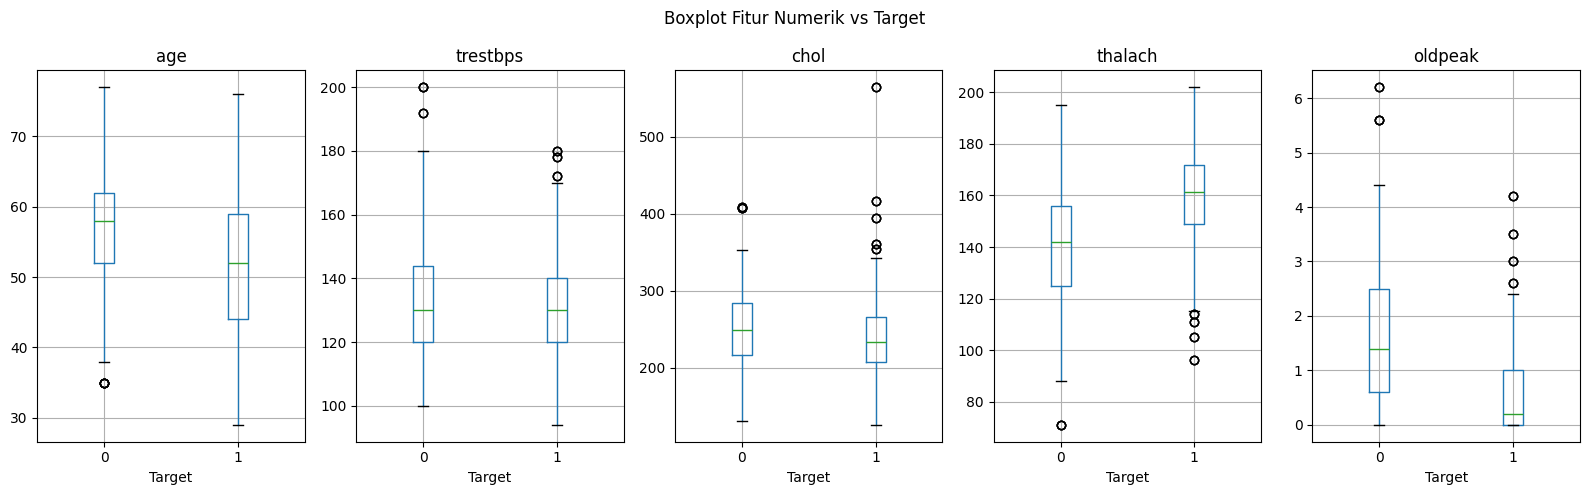

In [8]:
# --- 4.6 Boxplot of numerical features vs target ---
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 5))
for ax, col in zip(axes, numerical_cols):
    df.boxplot(column=col, by='target', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Target')
plt.suptitle('Boxplot of Numerical Features vs Target')
plt.tight_layout()
plt.show()

**Insights from EDA:**
- Dataset consists of 303 samples with 13 features and 1 target column.
- Class distribution is fairly balanced: ~54% heart disease, ~46% normal.
- `thalach` (max heart rate) and `cp` (chest pain type) are positively correlated with the target.
- `oldpeak` and `exang` are negatively correlated with the target.
- Some duplicates found that will be handled during preprocessing.
- No missing values in this dataset.

# **5. Data Preprocessing**

Preprocessing steps:
1. Remove duplicate data
2. Separate features (X) and labels (y)
3. Normalize features using StandardScaler
4. Split data into train-test (80:20) with stratification
5. Save results to `.npy` files

In [9]:
# --- 5.1 Remove duplicates ---
print(f'Before removing duplicates: {df.shape}')
df = df.drop_duplicates()
print(f'After removing duplicates: {df.shape}')

Sebelum hapus duplikat: (1025, 14)
Setelah hapus duplikat : (302, 14)


In [10]:
# --- 5.2 Separate features and labels ---
X = df.drop('target', axis=1).values
y = df['target'].values

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'y distribution: {np.bincount(y)}')

Shape X: (302, 13)
Shape y: (302,)
Distribusi y: [138 164]


In [11]:
# --- 5.3 Normalize with StandardScaler ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling (mean, std):')
print(f'  mean: {X.mean(axis=0).round(2)}')
print(f'  std : {X.std(axis=0).round(2)}')
print('\\nAfter scaling (mean, std):')
print(f'  mean: {X_scaled.mean(axis=0).round(3)}')
print(f'  std : {X_scaled.std(axis=0).round(3)}')

Sebelum scaling (mean, std):
  mean: [5.4420e+01 6.8000e-01 9.6000e-01 1.3160e+02 2.4650e+02 1.5000e-01
 5.3000e-01 1.4957e+02 3.3000e-01 1.0400e+00 1.4000e+00 7.2000e-01
 2.3100e+00]
  std : [ 9.03  0.47  1.03 17.53 51.67  0.36  0.53 22.87  0.47  1.16  0.62  1.01
  0.61]

Setelah scaling (mean, std):
  mean: [-0. -0. -0. -0. -0.  0. -0. -0.  0. -0. -0. -0.  0.]
  std : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [12]:
# --- 5.4 Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train distribution: {np.bincount(y_train)}')
print(f'y_test  distribution: {np.bincount(y_test)}')

X_train: (241, 13) | X_test: (61, 13)
y_train distribusi: [110 131]
y_test  distribusi: [28 33]


In [13]:
# --- 5.5 Save preprocessing results ---
os.makedirs('heart_preprocessing', exist_ok=True)

np.save('heart_preprocessing/X_train.npy', X_train)
np.save('heart_preprocessing/X_test.npy',  X_test)
np.save('heart_preprocessing/y_train.npy', y_train)
np.save('heart_preprocessing/y_test.npy',  y_test)

print('Preprocessing complete! Files saved to heart_preprocessing/')
print(os.listdir('heart_preprocessing'))

Preprocessing selesai! File tersimpan di heart_preprocessing/
['X_test.npy', 'y_train.npy', 'X_train.npy', 'y_test.npy']
